Préparation de l’environnement


In [1]:
import os
from pyspark.sql.functions import col, when, count, regexp_replace
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import cudf
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

Récupération du dataset

In [2]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv

--2025-12-14 09:42:38--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’

WA_Fn-UseC_-Telco-C 100%[===================>] 954.59K  --.-KB/s    in 0.01s   

2025-12-14 09:42:38 (81.2 MB/s) - ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’ saved [977501/977501]



In [3]:
!nvidia-smi
!pip install -q cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com
print("RAPIDS installé avec succès.")

Sun Dec 14 09:42:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import cudf

# Chargement GPU du dataset
gdf = cudf.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset chargé sur GPU avec RAPIDS")
gdf.head()

Dataset chargé sur GPU avec RAPIDS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Nettoyage TotalCharges (espaces, valeurs vides -> NaN -> 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip().replace('', np.nan), errors='coerce').fillna(0.0)
# Convertir label
df['Churn'] = df['Churn'].astype(str).str.strip().map(lambda x: 1 if x == "Yes" else 0)
# Prendre les colonnes numériques choisies (pour la démo RAPIDS)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_pd = df[num_cols].copy()
y_pd = df['Churn'].copy()

print("Taille dataset:", df.shape)
print("Répartition Churn (global):")
print(y_pd.value_counts())
X_pd.head()

Taille dataset: (7043, 21)
Répartition Churn (global):
Churn
0    5174
1    1869
Name: count, dtype: int64


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [7]:
X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(
    X_pd, y_pd, test_size=0.3, random_state=42, stratify=y_pd
)

print("Répartition train (pandas):")
print(y_train_pd.value_counts(normalize=False))
print("Répartition test (pandas):")
print(y_test_pd.value_counts(normalize=False))

Répartition train (pandas):
Churn
0    3622
1    1308
Name: count, dtype: int64
Répartition test (pandas):
Churn
0    1552
1     561
Name: count, dtype: int64


In [8]:
X_train = cudf.DataFrame.from_pandas(X_train_pd.astype('float32'))
X_test  = cudf.DataFrame.from_pandas(X_test_pd.astype('float32'))
y_train = cudf.Series(y_train_pd.astype('int32'))
y_test  = cudf.Series(y_test_pd.astype('int32'))
print("Données converties en cuDF (GPU).")

Données converties en cuDF (GPU).


In [9]:
def final_check_and_clean(X_train, X_test):
    # X can be pandas or cudf
    # replace inf, -inf with 0, fillna 0
    try:
        X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
        X_test  = X_test.replace([np.inf, -np.inf], 0).fillna(0)
    except Exception:
        # cudf replace uses cupy; fallback:
        X_train = X_train.fillna(0)
        X_test  = X_test.fillna(0)
    # remove constant columns (zero variance) to avoid solver issues
    if hasattr(X_train, "var"):
        var_train = X_train.var()
        # for cudf Series var returns scalars; for DataFrame returns Series-like
        mask = (var_train > 0)
        try:
            # pandas case: mask is Series indexed by columns
            keep_cols = mask[mask].index.tolist()
            X_train = X_train[keep_cols]
            X_test  = X_test[keep_cols]
        except Exception:
            # cudf case: mask may be cudf.Series; convert to pandas bool index
            mask_pd = mask.to_pandas()
            keep_cols = mask_pd[mask_pd].index.tolist()
            X_train = X_train[keep_cols]
            X_test  = X_test[keep_cols]
    return X_train, X_test

X_train, X_test = final_check_and_clean(X_train, X_test)
print("Final check done. Shapes:", getattr(X_train, 'shape', None), getattr(X_test, 'shape', None))


Final check done. Shapes: (4930, 3) (2113, 3)


In [10]:
results = {}

# Use cuML RandomForest (stable)
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.metrics import accuracy_score as cu_acc, roc_auc_score as cu_auc
import cupy as cp

model = cuRF(n_estimators=100, max_depth=7, random_state=42)

t0 = time.time()
model.fit(X_train, y_train)
t_gpu = time.time() - t0

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
# ensure we get the positive-class probability column
try:
    # cudf DataFrame case
    pos_prob = y_proba.iloc[:, 1].values
except Exception:
    # numpy array
    pos_prob = y_proba[:, 1]

acc = float(cu_acc(y_test, y_pred))
# compute AUC only if both classes present
if cp.unique(y_test).shape[0] > 1:
    auc = float(cu_auc(y_test, pos_prob))
else:
    auc = None

results['backend'] = 'RAPIDS'
results['acc'] = acc
results['auc'] = auc
results['time'] = t_gpu

print("Results:", results)

Results: {'backend': 'RAPIDS', 'acc': 0.7865593942262187, 'auc': 0.8182306289672852, 'time': 5.487702369689941}


,backend,acc,auc,time
0,RAPIDS,0.786559,0.818231,5.487702


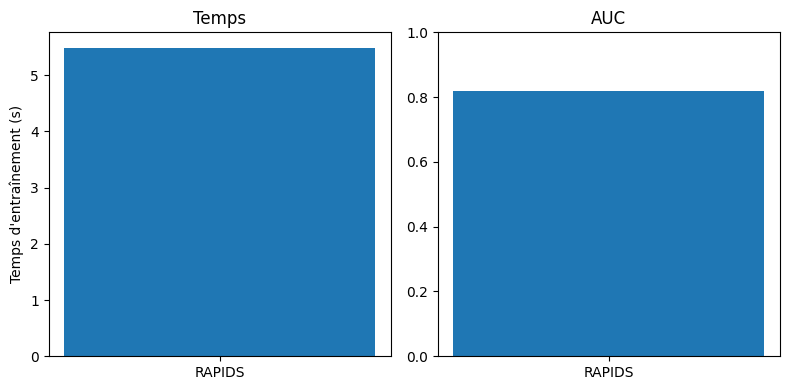

In [11]:
df_res = pd.DataFrame([results])
display(df_res)

# simple bar chart sur temps et AUC
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.bar([results['backend']], [results['time']])
plt.ylabel("Temps d'entraînement (s)")
plt.title("Temps")

plt.subplot(1,2,2)
if results['auc'] is not None:
    plt.bar([results['backend']], [results['auc']])
    plt.ylim(0.0,1.0)
    plt.title("AUC")
else:
    plt.text(0.1, 0.5, "AUC non défini (une classe manquante dans test)", fontsize=10)
    plt.title("AUC")
plt.tight_layout()
plt.show()